In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [2]:
df = pd.read_csv("../data/spotify_data_clean.csv")

In [3]:
df["artist_followers_log"] = np.log1p(df["artist_followers"])
df["artist_impact"] = df["artist_followers_log"] * df["artist_popularity"]
df["release_year"] = pd.to_datetime(df["album_release_date"]).dt.year

features = [
    "artist_impact",
    "track_duration_min",
    "album_total_tracks"
]

features_2 = [
    "artist_popularity",
    "artist_followers",
    "track_duration_min",
    "album_total_tracks"
]

X = df[features].copy()

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
#PCA to justify feature selection

pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pd.DataFrame(
    {
        "component": np.arange(1, len(features) + 1),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca_full.explained_variance_ratio_),
    }
)

threshold_summary = pd.DataFrame(
    {
        "variance_threshold": [0.70, 0.80, 0.90, 0.95],
        "components_needed": [
            np.searchsorted(explained_variance["cumulative_explained_variance"], threshold) + 1
            for threshold in [0.70, 0.80, 0.90, 0.95]
        ],
    }
)

display(threshold_summary)
explained_variance.head(10)

,variance_threshold,components_needed
0,0.70,2
1,0.80,3
2,0.90,3
3,0.95,3


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.447854,0.447854
1,2,0.312030,0.759884
2,3,0.240116,1.000000


In [6]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    index = features,
    columns=[f"PC{i}" for i in range(1, len(features) + 1)],
)

def top_loadings(component, top_n=4):
    out = pd.DataFrame(
        {
            "loading": loadings[component],
            "abs_loading": loadings[component].abs(),
        }
    )
    return out.sort_values("abs_loading", ascending=False).head(top_n)

print("Top loadings for PC1")
display(top_loadings("PC1"))
print("Top loadings for PC2")
display(top_loadings("PC2"))
print("Top loadings for PC3")
display(top_loadings("PC3"))

Top loadings for PC1


,loading,abs_loading
artist_impact,0.669524,0.669524
track_duration_min,0.553268,0.553268
album_total_tracks,0.495612,0.495612


Top loadings for PC2


,loading,abs_loading
album_total_tracks,0.765948,0.765948
track_duration_min,-0.641861,0.641861
artist_impact,-0.036582,0.036582


Top loadings for PC3


,loading,abs_loading
artist_impact,0.741889,0.741889
track_duration_min,-0.530951,0.530951
album_total_tracks,-0.409502,0.409502


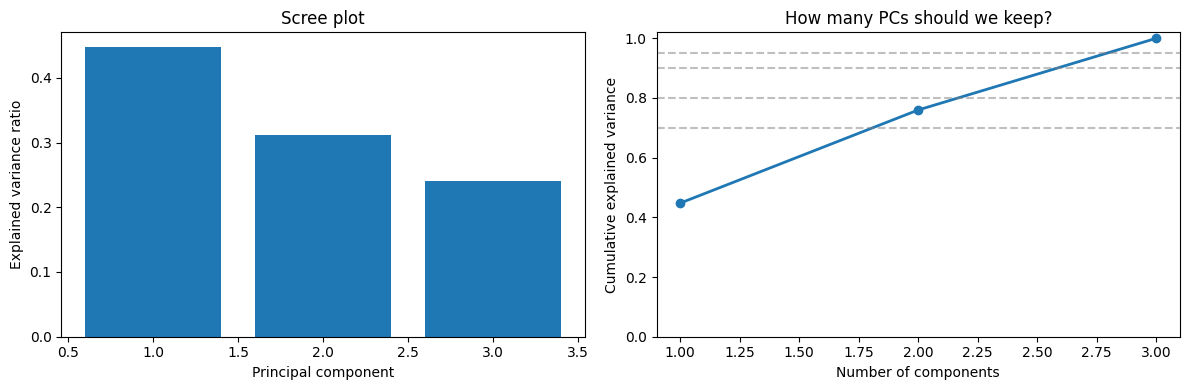

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(
    explained_variance["component"],
    explained_variance["explained_variance_ratio"],
    #color="#4c72b0",
)
ax[0].set_xlabel("Principal component")
ax[0].set_ylabel("Explained variance ratio")
ax[0].set_title("Scree plot")

ax[1].plot(
    explained_variance["component"],
    explained_variance["cumulative_explained_variance"],
    marker="o",
    linewidth=2,
    #color="#dd8452",
)
for threshold in [0.70, 0.80, 0.90, 0.95]:
    ax[1].axhline(threshold, linestyle="--", color="gray", alpha=0.5)
ax[1].set_xlabel("Number of components")
ax[1].set_ylabel("Cumulative explained variance")
ax[1].set_title("How many PCs should we keep?")
ax[1].set_ylim(0, 1.02)

plt.tight_layout()

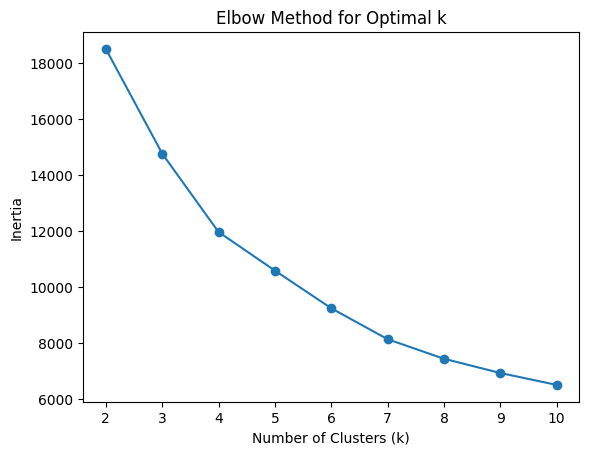

In [8]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [9]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette score={score:.3f}")

k=2, silhouette score=0.300
k=3, silhouette score=0.328
k=4, silhouette score=0.306
k=5, silhouette score=0.306
k=6, silhouette score=0.261
k=7, silhouette score=0.273
k=8, silhouette score=0.275
k=9, silhouette score=0.275
k=10, silhouette score=0.270


In [10]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

df["cluster"].value_counts()

cluster
0    5129
1    3077
2     376
Name: count, dtype: int64

In [11]:
cluster_summary = df.groupby("cluster")[features + ["track_popularity"]].mean()

cluster_summary

,artist_impact,track_duration_min,album_total_tracks,track_popularity
cluster,,,,
0,1357.340216,3.876567,14.117372,59.652759
1,655.423198,2.886240,8.506987,42.407865
2,1016.050631,3.221755,52.545213,34.236702


In [12]:
df["cluster"].value_counts().sort_index()

cluster
0    5129
1    3077
2     376
Name: count, dtype: int64

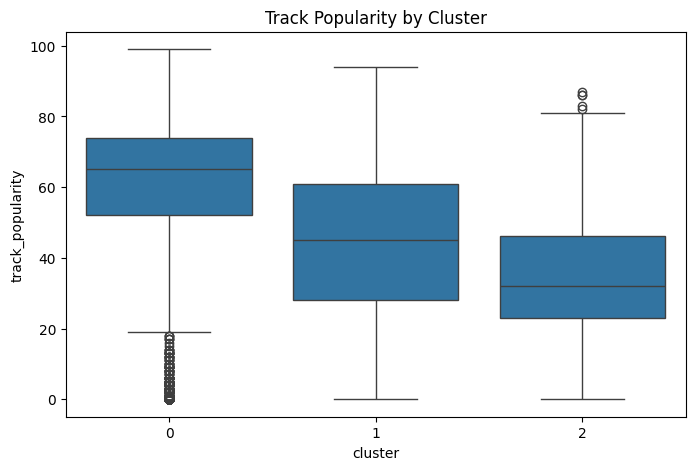

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cluster", y="track_popularity", data=df)
plt.title("Track Popularity by Cluster")
plt.show()

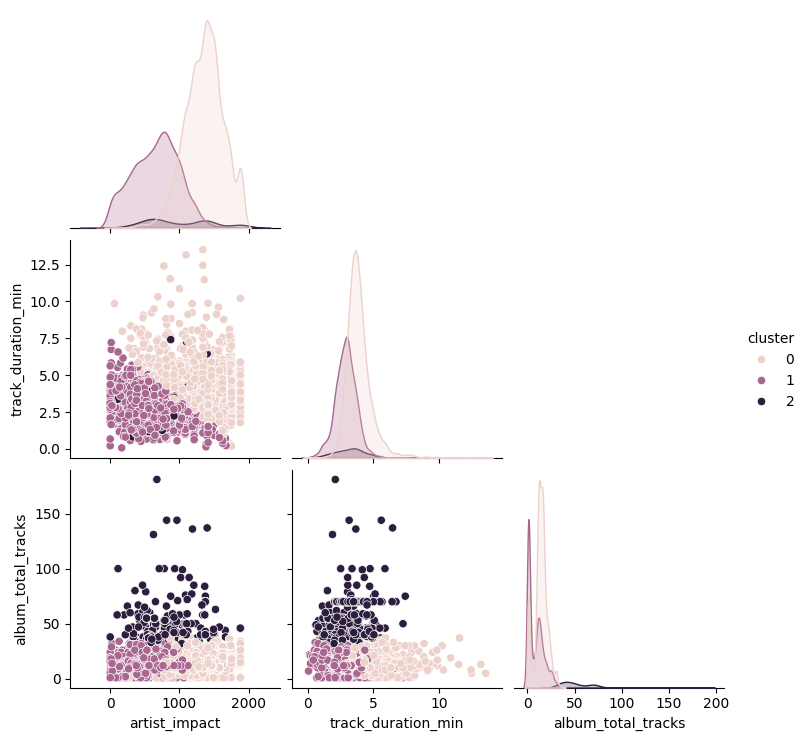

In [14]:
sns.pairplot(df, vars=features, hue="cluster", corner=True)